# Choose SegTHOR HU bounds
Run all cells with the **ai4mi** kernelc(`requirements-notebooks.txt`). Look at raw files (don't change paths if needed)

The defaults reproduce the current Makefile split.

In [1]:
# Load data
from pathlib import Path
import random
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ORGANS = {1: 'Esophagus', 2: 'Heart', 3: 'Trachea', 4: 'Aorta'}
patients = sorted(Path('data/segthor_part1_fixed/train').glob('Patient_*')) # make sure you use the fixed version of the dataset, not the original SegTHOR challenge data. 
#python slice_segthor.py \
#   --source_dir data/segthor_part1 \
#   --dest_dir data/SEGTHOR_fixed \
#   --shape 256 256 \
#   --fix_aorta_esophagus \
#   --retains 5
organ_values = {k: [] for k in ORGANS}
for patient in patients:
    ct = nib.load(patient / f'{patient.name}.nii.gz').get_fdata(dtype=np.float32)
    mask = np.asanyarray(nib.load(patient / 'GT.nii.gz').dataobj)
    for k in ORGANS:
        organ_values[k].append(ct[mask == k])
organ_values = {k: np.concatenate(v) for k, v in organ_values.items()}


,0% HU,0.1% HU,0.5% HU,1% HU,5% HU,95% HU,99% HU,99.5% HU,99.7% HU,99.9% HU,100% HU
organ,,,,,,,,,,,
Esophagus,-1000.0,-1000.0,-1000.0,-982.0,-220.0,99.0,213.0,222.0,228.0,257.0625,2264.0
Heart,-1000.0,-320.0,-158.0,-132.0,-81.0,165.0,217.0,257.0,292.0,409.0000,7095.0
Trachea,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-248.0,-38.0,55.0,134.0,252.0000,3071.0
Aorta,-989.0,-258.0,-60.0,-35.0,3.0,200.0,232.0,246.0,265.0,450.0000,1578.0


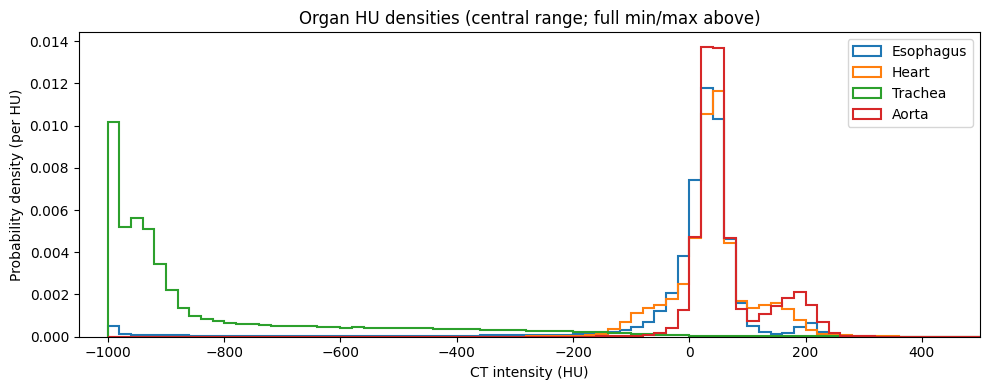

In [2]:
percentiles = [0.0, 0.1, 0.5, 1, 5, 95, 99, 99.5,99.7, 99.9, 100]

display(pd.DataFrame([
    {
        'organ': ORGANS[k],
        **{f'{p:g}% HU': np.percentile(v, p) if v.size else np.nan
           for p in percentiles},
    }
    for k, v in organ_values.items()
]).set_index('organ'))

present = {ORGANS[k]: v for k, v in organ_values.items() if v.size}
bins = np.arange(min(v.min() for v in present.values()),
                 max(v.max() for v in present.values()) + 20, 20)
plt.figure(figsize=(10, 4))
for organ, values in present.items():
    plt.hist(values, bins=bins, density=True, histtype='step', linewidth=1.5, label=organ)
plt.xlabel('CT intensity (HU)')
plt.ylabel('Probability density (per HU)')
plt.xlim(-1050, 500)  # lets not show the full tail.
plt.title('Organ HU densities (central range; full min/max above)')
plt.legend()
plt.tight_layout()
plt.show()

The tail of HU-max is very long, the best compromise seems to be -1000, 300.